## **5. 위생 데이터 추가**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
plt.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['font.family'] = 'Malgun Gothic'

df = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/광진구 가격점수 원본.csv")
df.head()

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수
0,소이동갈비 (4대),25000,대가숯불갈비,갈비,자양동,18934.48,0.000000
1,소양념왕갈비(300g),23000,마포갈비,갈비,구의동,18934.48,0.000000
2,차돌된장찌개,10000,서울숯불갈비,갈비,구의동,18934.48,33.030408
3,삼겹살(200g),18000,낙천정,갈비,자양동,18934.48,3.454734
4,김치품은등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48,14.545612


In [2]:
df_mobum = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/광진구 모범음식점 업소.csv", encoding='cp949')
df_bad = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/광진구 요식업 처분내역.csv", encoding='cp949')
df_good = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/광진구 위생등급 업소.csv", encoding='cp949')


### **어떤 기준으로 점수를 부여할 것인가?**

일단 위생점수의 만점은 30점이다. 

모범음식점 업소: '모범음식점'의 경우 30/30 점을 부여한다. (만점 기준)

            '급수시설구분' 이 '상수도 전용'인 경우 30점을, 'NaN'인 경우 25점을 부여한다. 

위생등급 업소: '메우우수'의 경우 20/30 점을 부여하고, '우수'의 경우 15점을 부여한다.

데이터가 없는 경우: 기본점수 8/30 점을 부여한다. 

위생처분 업소: 많은 패널티를 주기 위해 -30점을 부여한다. (음수 점수 부여)

In [3]:
df_mobum.head()

,시군구코드,지정년도,지정번호,신청일자,지정일자,업소명,소재지도로명,소재지지번,허가(신고)번호,업태명,주된음식,영업장면적(㎡),행정동명,급수시설구분,소재지전화번호
0,3040000,2016,6,20161021,20161021,명가네남원추어탕,"서울특별시 광진구 능동로37길 11, 1층 (중곡동)",서울특별시 광진구 중곡동 649번지 13호 1층,3040000-101-2016-00001,한식,추어탕,170.00,중곡제1동,NaN,02 4615977
1,3040000,2008,5568,20081024,20081201,부림정,"서울특별시 광진구 뚝섬로 476-7, (자양동)",서울특별시 광진구 자양동 52번지 2호,3040000-101-1979-00456,한식,갈비,112.10,자양제4동,상수도전용,02 4635455
2,3040000,2005,5449,20051111,20051111,대원칼국수,"서울특별시 광진구 자양로18길 56, 거송빌딩 2층 (구의동)",서울특별시 광진구 구의동 243번지 6호 거송빌딩,3040000-101-1987-00710,분식,칼국수,132.44,구의제1동,상수도전용,02 4543112
3,3040000,1998,5090,19980220,19980220,송화,"서울특별시 광진구 아차산로51길 24, 1~2층 (구의동)",서울특별시 광진구 구의동 257번지 129호,3040000-101-1981-00796,한식,"돼지갈비, 삼겹살",171.99,구의제1동,상수도전용,02 4476780
4,3040000,2013,5653,20130730,20130912,송화양꼬치,"서울특별시 광진구 동일로18길 70, (자양동)",서울특별시 광진구 자양동 11번지 2호,3040000-101-1985-01014,중국식,양꼬치,127.19,자양제4동,상수도전용,02 4627826


In [4]:
df_mobum.columns

Index(['시군구코드', '지정년도', '지정번호', '신청일자', '지정일자', '업소명', '소재지도로명', '소재지지번',
       '허가(신고)번호', '업태명', '주된음식', '영업장면적(㎡)', '행정동명', '급수시설구분', '소재지전화번호'],
      dtype='object')

In [5]:
drop_cols = ['시군구코드', '지정년도', '지정번호', '신청일자', '지정일자','소재지도로명', '소재지지번',
       '허가(신고)번호','영업장면적(㎡)', '행정동명','소재지전화번호']
df_mobum.drop(columns= drop_cols, inplace=True)
df_mobum.head()

,업소명,업태명,주된음식,급수시설구분
0,명가네남원추어탕,한식,추어탕,NaN
1,부림정,한식,갈비,상수도전용
2,대원칼국수,분식,칼국수,상수도전용
3,송화,한식,"돼지갈비, 삼겹살",상수도전용
4,송화양꼬치,중국식,양꼬치,상수도전용


In [6]:
def 점수계산(row):
    평가기준 = row['급수시설구분']
    
    if 평가기준 == '상수도전용':
        score = 30
    else:
        score = 25
    
    return score

df_mobum['위생점수'] = df_mobum.apply(점수계산, axis=1)
df_mobum.head()

,업소명,업태명,주된음식,급수시설구분,위생점수
0,명가네남원추어탕,한식,추어탕,NaN,25
1,부림정,한식,갈비,상수도전용,30
2,대원칼국수,분식,칼국수,상수도전용,30
3,송화,한식,"돼지갈비, 삼겹살",상수도전용,30
4,송화양꼬치,중국식,양꼬치,상수도전용,30


In [7]:
df_bad.head()

,시군구코드,처분일자,교부번호,업종명,업태명,업소명,소재지도로명,소재지지번,지도점검일자,행정처분상태,처분명,법적근거,위반일자,위반내용,처분내용,처분기간,영업장면적(㎡),운영형태
0,3040000,19940829,19740039004,일반음식점,한식,풍차집,NaN,서울특별시 광진구 광장동 산 189번지 30호,19940829.0,처분확정,(),NaN,19940829,(),(),NaN,35.96,NaN
1,3040000,19950511,19740039004,일반음식점,한식,풍차집,NaN,서울특별시 광진구 광장동 산 189번지 30호,19950511.0,처분확정,(),NaN,19950511,(),(),15.0,35.96,NaN
2,3040000,19981105,19740039004,일반음식점,한식,풍차집,NaN,서울특별시 광진구 광장동 산 189번지 30호,19981105.0,처분확정,(),NaN,19981105,(),(),30.0,35.96,NaN
3,3040000,19940514,19750039002,일반음식점,한식,함부르크,NaN,서울특별시 광진구 화양동 산 212번지 0호,19940514.0,처분확정,(),NaN,19940514,(),(),0.0,128.72,NaN
4,3040000,19940829,19760039011,일반음식점,한식,버드나무집,NaN,서울특별시 광진구 광장동 산 319번지 1호,19940829.0,처분확정,(),NaN,19940829,(),(),0.0,628.10,NaN


In [8]:
df_bad.columns

Index(['시군구코드', '처분일자', '교부번호', '업종명', '업태명', '업소명', '소재지도로명', '소재지지번',
       '지도점검일자', '행정처분상태', '처분명', '법적근거', '위반일자', '위반내용', '처분내용', '처분기간',
       '영업장면적(㎡)', '운영형태'],
      dtype='object')

In [9]:
drop_cols = ['시군구코드', '처분일자', '교부번호','업종명','소재지도로명', '소재지지번',
       '지도점검일자','처분명', '법적근거', '위반일자', '위반내용', '처분내용', '처분기간',
       '영업장면적(㎡)', '운영형태']
# df_bad.drop(columns = drop_cols, inplace=True)
df_bad.head()

,시군구코드,처분일자,교부번호,업종명,업태명,업소명,소재지도로명,소재지지번,지도점검일자,행정처분상태,처분명,법적근거,위반일자,위반내용,처분내용,처분기간,영업장면적(㎡),운영형태
0,3040000,19940829,19740039004,일반음식점,한식,풍차집,NaN,서울특별시 광진구 광장동 산 189번지 30호,19940829.0,처분확정,(),NaN,19940829,(),(),NaN,35.96,NaN
1,3040000,19950511,19740039004,일반음식점,한식,풍차집,NaN,서울특별시 광진구 광장동 산 189번지 30호,19950511.0,처분확정,(),NaN,19950511,(),(),15.0,35.96,NaN
2,3040000,19981105,19740039004,일반음식점,한식,풍차집,NaN,서울특별시 광진구 광장동 산 189번지 30호,19981105.0,처분확정,(),NaN,19981105,(),(),30.0,35.96,NaN
3,3040000,19940514,19750039002,일반음식점,한식,함부르크,NaN,서울특별시 광진구 화양동 산 212번지 0호,19940514.0,처분확정,(),NaN,19940514,(),(),0.0,128.72,NaN
4,3040000,19940829,19760039011,일반음식점,한식,버드나무집,NaN,서울특별시 광진구 광장동 산 319번지 1호,19940829.0,처분확정,(),NaN,19940829,(),(),0.0,628.10,NaN


In [10]:
df_bad['위생점수'] = -30
df_bad.head()

,시군구코드,처분일자,교부번호,업종명,업태명,업소명,소재지도로명,소재지지번,지도점검일자,행정처분상태,처분명,법적근거,위반일자,위반내용,처분내용,처분기간,영업장면적(㎡),운영형태,위생점수
0,3040000,19940829,19740039004,일반음식점,한식,풍차집,NaN,서울특별시 광진구 광장동 산 189번지 30호,19940829.0,처분확정,(),NaN,19940829,(),(),NaN,35.96,NaN,-30
1,3040000,19950511,19740039004,일반음식점,한식,풍차집,NaN,서울특별시 광진구 광장동 산 189번지 30호,19950511.0,처분확정,(),NaN,19950511,(),(),15.0,35.96,NaN,-30
2,3040000,19981105,19740039004,일반음식점,한식,풍차집,NaN,서울특별시 광진구 광장동 산 189번지 30호,19981105.0,처분확정,(),NaN,19981105,(),(),30.0,35.96,NaN,-30
3,3040000,19940514,19750039002,일반음식점,한식,함부르크,NaN,서울특별시 광진구 화양동 산 212번지 0호,19940514.0,처분확정,(),NaN,19940514,(),(),0.0,128.72,NaN,-30
4,3040000,19940829,19760039011,일반음식점,한식,버드나무집,NaN,서울특별시 광진구 광장동 산 319번지 1호,19940829.0,처분확정,(),NaN,19940829,(),(),0.0,628.10,NaN,-30


In [11]:
df_good.head()

,연번,지정기관,지정일자,지정등급,업소명,영업자명,소재지(도로명),업종명,법정동명(식품영업대장)
0,1,식품의약품안전처,2023-05-23,매우우수,(유)아웃백스테이크하우스코리아 건대스타시티점,박*종,서울특별시 광진구 능동로 92(롯데백화점 스타시티몰 2층 자양동),일반음식점,자양동
1,2,식품의약품안전처,2024-08-09,매우우수,(주)핫시즈너동대문엽기떡볶이,금*일,서울특별시 광진구 동일로22길 111(화양동),일반음식점,화양동
2,3,식품의약품안전처,2024-04-15,매우우수,60계 서울군자점,안*진,서울특별시 광진구 면목로 1(1층 군자동),일반음식점,군자동
3,4,식품의약품안전처,2024-05-29,매우우수,60계구의광장점,이*훈,서울특별시 광진구 광나루로56길 34(구의현대2단지 지층 14호 구의동),일반음식점,구의동
4,5,식품의약품안전처,2023-08-20,매우우수,BHC중곡점,조*미,서울특별시 광진구 능동로 327(중곡동),일반음식점,중곡동


In [12]:
df_good.columns

Index(['연번', '지정기관', '지정일자', '지정등급', '업소명', '영업자명', '소재지(도로명)', '업종명',
       '법정동명(식품영업대장)'],
      dtype='object')

In [13]:
drop_cols = ['연번', '지정기관', '지정일자','영업자명','소재지(도로명)', '업종명','법정동명(식품영업대장)']
df_good.drop(columns = drop_cols, inplace=True)

def 점수계산(row):
    평가기준 = row['지정등급']

    if 평가기준 == '매우우수':
        score = 20
    elif 평가기준 == '우수':
        score = 15
    else:
        score = 8
    return score

df_good['위생점수'] = df_good.apply(점수계산, axis=1)
df_good.head()

,지정등급,업소명,위생점수
0,매우우수,(유)아웃백스테이크하우스코리아 건대스타시티점,20
1,매우우수,(주)핫시즈너동대문엽기떡볶이,20
2,매우우수,60계 서울군자점,20
3,매우우수,60계구의광장점,20
4,매우우수,BHC중곡점,20


In [14]:
df_result = pd.concat([
    df_mobum[['업소명', '위생점수']],
    df_bad[['업소명', '위생점수']],
    df_good[['업소명', '위생점수']]
], ignore_index=True)

df_result.head()

,업소명,위생점수
0,명가네남원추어탕,25
1,부림정,30
2,대원칼국수,30
3,송화,30
4,송화양꼬치,30


In [15]:
df_result = df_result.rename(columns={'업소명': '가게명'})
df['위생점수'] = 0
df.head()

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수,위생점수
0,소이동갈비 (4대),25000,대가숯불갈비,갈비,자양동,18934.48,0.000000,0
1,소양념왕갈비(300g),23000,마포갈비,갈비,구의동,18934.48,0.000000,0
2,차돌된장찌개,10000,서울숯불갈비,갈비,구의동,18934.48,33.030408,0
3,삼겹살(200g),18000,낙천정,갈비,자양동,18934.48,3.454734,0
4,김치품은등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48,14.545612,0


In [16]:
df.columns

Index(['메뉴', '가격', '가게명', '주메뉴', '동', '평균가격', '가격점수', '위생점수'], dtype='object')

In [17]:
df_result = df_result.drop_duplicates(subset='가게명', keep='first')


In [18]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6507 entries, 0 to 15656
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   가게명     6507 non-null   object
 1   위생점수    6507 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 152.5+ KB


In [19]:
df_result = df_result.set_index('가게명')
df['위생점수'] = df['가게명'].map(df_result['위생점수'])

df['위생점수'] = df['위생점수'].fillna(8)

df.head()

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수,위생점수
0,소이동갈비 (4대),25000,대가숯불갈비,갈비,자양동,18934.48,0.000000,-30.0
1,소양념왕갈비(300g),23000,마포갈비,갈비,구의동,18934.48,0.000000,-30.0
2,차돌된장찌개,10000,서울숯불갈비,갈비,구의동,18934.48,33.030408,8.0
3,삼겹살(200g),18000,낙천정,갈비,자양동,18934.48,3.454734,8.0
4,김치품은등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48,14.545612,8.0


In [20]:
df.head()

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수,위생점수
0,소이동갈비 (4대),25000,대가숯불갈비,갈비,자양동,18934.48,0.000000,-30.0
1,소양념왕갈비(300g),23000,마포갈비,갈비,구의동,18934.48,0.000000,-30.0
2,차돌된장찌개,10000,서울숯불갈비,갈비,구의동,18934.48,33.030408,8.0
3,삼겹살(200g),18000,낙천정,갈비,자양동,18934.48,3.454734,8.0
4,김치품은등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48,14.545612,8.0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   메뉴      4653 non-null   object 
 1   가격      4653 non-null   int64  
 2   가게명     4653 non-null   object 
 3   주메뉴     4653 non-null   object 
 4   동       4653 non-null   object 
 5   평균가격    4653 non-null   float64
 6   가격점수    4653 non-null   float64
 7   위생점수    4653 non-null   float64
dtypes: float64(3), int64(1), object(4)
memory usage: 290.9+ KB


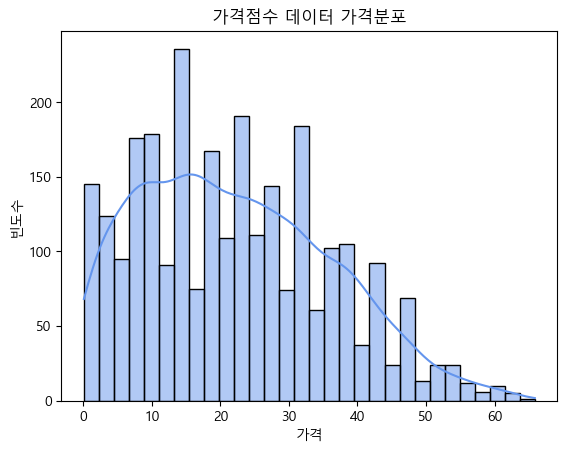

In [22]:
sns.histplot(data=df[df['가격점수'] > 0], x='가격점수', bins=30, kde=True, color='cornflowerblue')
plt.title('가격점수 데이터 가격분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [23]:
df['총 점수'] = df['가격점수']+df['위생점수']

df.head()

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수,위생점수,총 점수
0,소이동갈비 (4대),25000,대가숯불갈비,갈비,자양동,18934.48,0.000000,-30.0,-30.000000
1,소양념왕갈비(300g),23000,마포갈비,갈비,구의동,18934.48,0.000000,-30.0,-30.000000
2,차돌된장찌개,10000,서울숯불갈비,갈비,구의동,18934.48,33.030408,8.0,41.030408
3,삼겹살(200g),18000,낙천정,갈비,자양동,18934.48,3.454734,8.0,11.454734
4,김치품은등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48,14.545612,8.0,22.545612


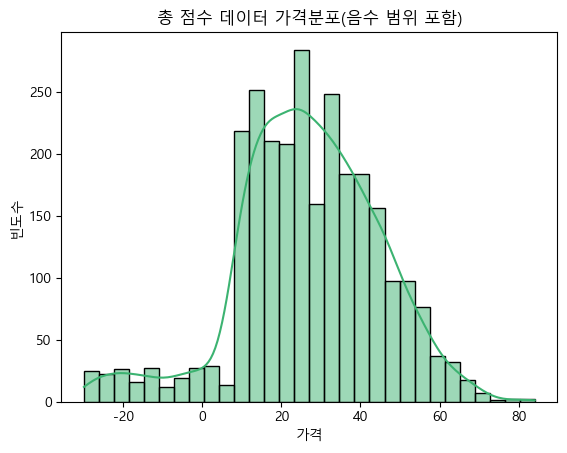

In [24]:
matplotlib.rcParams['axes.unicode_minus'] = False

sns.histplot(data=df[df['가격점수'] > 0], x='총 점수', bins=30, kde=True, color='mediumseagreen')
plt.title('총 점수 데이터 가격분포(음수 범위 포함)')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [25]:
df_filtered = df[df['가격점수']>0]

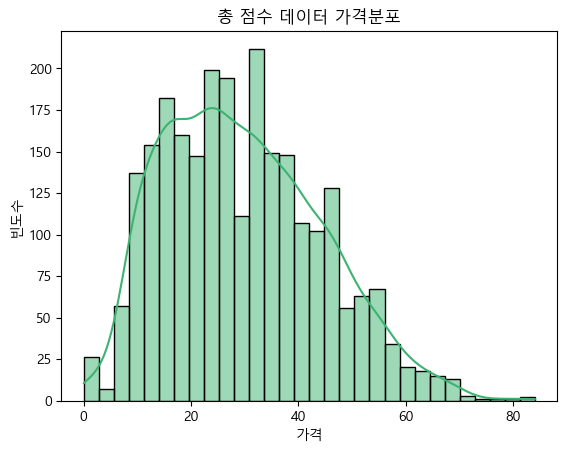

In [26]:

sns.histplot(data=df_filtered[df_filtered['총 점수'] > 0],
              x='총 점수', bins=30, kde=True, color='mediumseagreen')
plt.title('총 점수 데이터 가격분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [27]:
df_filtered.head()

,메뉴,가격,가게명,주메뉴,동,평균가격,가격점수,위생점수,총 점수
2,차돌된장찌개,10000,서울숯불갈비,갈비,구의동,18934.48,33.030408,8.0,41.030408
3,삼겹살(200g),18000,낙천정,갈비,자양동,18934.48,3.454734,8.0,11.454734
4,김치품은등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48,14.545612,8.0,22.545612
5,제육볶음,10000,59년왕십리돼지숯불갈비 성수점,갈비,자양동,18934.48,33.030408,8.0,41.030408
6,등갈비찜,15000,김치품은 등갈비,갈비,구의동,18934.48,14.545612,8.0,22.545612


In [ ]:
df_filtered.to_csv('광진구 총 점수.csv', index=False, encoding='utf-8-sig1')

## **6. 지역화폐 데이터 추가**

In [30]:
df_zero = pd.read_csv("C:/Users/UserPC/OneDrive/00 공모전/지역화폐_최종.csv")
df_zero.head()

,가게명,지역화폐,메뉴,가격,주메뉴,동,평균가격,가격점수,위생점수,총 점수
0,서울숯불갈비,X,차돌된장찌개,10000,갈비,구의동,18934.48,36.969592,8.0,44.969592
1,낙천정,O,삼겹살(200g),18000,갈비,자양동,18934.48,66.545266,8.0,74.545266
2,김치품은 등갈비,O,김치품은등갈비찜,15000,갈비,구의동,18934.48,55.454388,8.0,63.454388
3,59년왕십리돼지숯불갈비 성수점,X,제육볶음,10000,갈비,자양동,18934.48,36.969592,8.0,44.969592
4,마포숯불갈비,X,숯불갈비 (1인),15000,갈비,자양동,18934.48,55.454388,-30.0,25.454388


In [31]:
df_zero.isna().sum()

가게명     0
지역화폐    0
메뉴      0
가격      0
주메뉴     0
동       0
평균가격    0
가격점수    0
위생점수    0
총 점수    0
dtype: int64

In [32]:
df_filtered = df_zero[df_zero['지역화폐']=='O']
df_filtered.head()

,가게명,지역화폐,메뉴,가격,주메뉴,동,평균가격,가격점수,위생점수,총 점수
1,낙천정,O,삼겹살(200g),18000,갈비,자양동,18934.48,66.545266,8.0,74.545266
2,김치품은 등갈비,O,김치품은등갈비찜,15000,갈비,구의동,18934.48,55.454388,8.0,63.454388
7,명숯불갈비,O,돼지갈비 1인분 200g,15000,갈비,자양동,18934.48,55.454388,8.0,63.454388
9,대가숯불갈비,O,돼지갈비 (250g),17000,갈비,자양동,18934.48,62.848306,-30.0,32.848306
11,서서갈비,O,안창살,12000,갈비,화양동,18934.48,44.363510,8.0,52.363510


In [33]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 621 entries, 1 to 1571
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   가게명     621 non-null    object 
 1   지역화폐    621 non-null    object 
 2   메뉴      621 non-null    object 
 3   가격      621 non-null    int64  
 4   주메뉴     621 non-null    object 
 5   동       621 non-null    object 
 6   평균가격    621 non-null    float64
 7   가격점수    621 non-null    float64
 8   위생점수    621 non-null    float64
 9   총 점수    621 non-null    float64
dtypes: float64(4), int64(1), object(5)
memory usage: 53.4+ KB


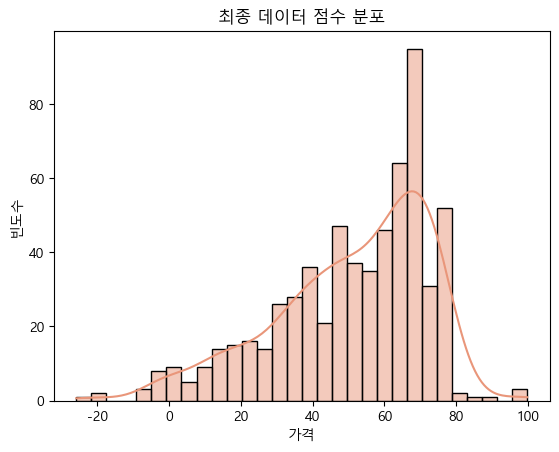

In [34]:
sns.histplot(data= df_filtered, x='총 점수', bins=30, kde=True, color='darksalmon')
plt.title('최종 데이터 점수 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [37]:
df_filtered = df_filtered[df_filtered['총 점수']>0]
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 606 entries, 1 to 1571
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   가게명     606 non-null    object 
 1   지역화폐    606 non-null    object 
 2   메뉴      606 non-null    object 
 3   가격      606 non-null    int64  
 4   주메뉴     606 non-null    object 
 5   동       606 non-null    object 
 6   평균가격    606 non-null    float64
 7   가격점수    606 non-null    float64
 8   위생점수    606 non-null    float64
 9   총 점수    606 non-null    float64
dtypes: float64(4), int64(1), object(5)
memory usage: 52.1+ KB


## **최종 데이터 확인**

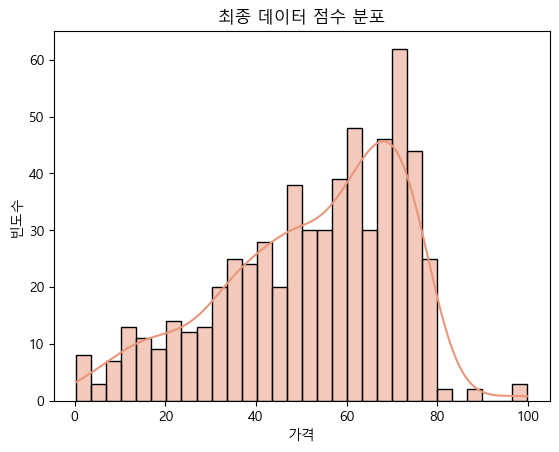

In [38]:
sns.histplot(data= df_filtered, x='총 점수', bins=30, kde=True, color='darksalmon')
plt.title('최종 데이터 점수 분포')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()

In [36]:
df_filtered.sort_values(by='총 점수').tail(30)

,가게명,지역화폐,메뉴,가격,주메뉴,동,평균가격,가격점수,위생점수,총 점수
1196,전설의짬뽕,O,짜장면,8000,중식,자양동,8158.91,68.636619,8.0,76.636619
1188,짠롱지아,O,삼선짬뽕,8000,중식,구의동,8158.91,68.636619,8.0,76.636619
1186,동화장,O,간짜장,8000,중식,중곡동,8158.91,68.636619,8.0,76.636619
1179,양가,O,고추짜장,8000,중식,구의동,8158.91,68.636619,8.0,76.636619
1212,바로반점 건대점,O,（인기）제주흑돼지 짜장면,8000,중식,화양동,8158.91,68.636619,8.0,76.636619
766,옛집,O,돼지찌개,10000,한식,광장동,14931.95,46.879343,30.0,76.879343
326,장군부대찌개,O,장군부대찌개,12000,"찌개,전골",군자동,16186.81,51.894104,25.0,76.894104
178,수작카츠 자양점,O,수작카츠,10500,"돈까스,우동",자양동,10659.55,68.952254,8.0,76.952254
463,바다와갯벌,O,광어(중),25000,"해물,생선",자양동,25275.83,69.236104,8.0,77.236104
348,다다미,O,물회,17000,"초밥,롤",능동,17142.11,69.419692,8.0,77.419692


In [40]:
df_final = df_filtered.sort_values(by='총 점수')
df_final.to_csv('광진구 점수 최종.csv', index=False, encoding='utf-8-sig')

In [41]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 606 entries, 387 to 1125
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   가게명     606 non-null    object 
 1   지역화폐    606 non-null    object 
 2   메뉴      606 non-null    object 
 3   가격      606 non-null    int64  
 4   주메뉴     606 non-null    object 
 5   동       606 non-null    object 
 6   평균가격    606 non-null    float64
 7   가격점수    606 non-null    float64
 8   위생점수    606 non-null    float64
 9   총 점수    606 non-null    float64
dtypes: float64(4), int64(1), object(5)
memory usage: 52.1+ KB


In [ ]:
duplicate_names = df_final[df_final['가게명'].duplicated()]
has_duplicates = df_final['가게명'].duplicated().any()

print("중복 여부:", has_duplicates)
print("중복된 가게명들:")
print(duplicate_names)


중복 여부: False
중복된 가게명들:
Empty DataFrame
Columns: [가게명, 지역화폐, 메뉴, 가격, 주메뉴, 동, 평균가격, 가격점수, 위생점수, 총 점수]
Index: []


In [43]:
df = df_filtered[df_filtered['총 점수']>=50]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 361 entries, 1 to 1571
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   가게명     361 non-null    object 
 1   지역화폐    361 non-null    object 
 2   메뉴      361 non-null    object 
 3   가격      361 non-null    int64  
 4   주메뉴     361 non-null    object 
 5   동       361 non-null    object 
 6   평균가격    361 non-null    float64
 7   가격점수    361 non-null    float64
 8   위생점수    361 non-null    float64
 9   총 점수    361 non-null    float64
dtypes: float64(4), int64(1), object(5)
memory usage: 31.0+ KB


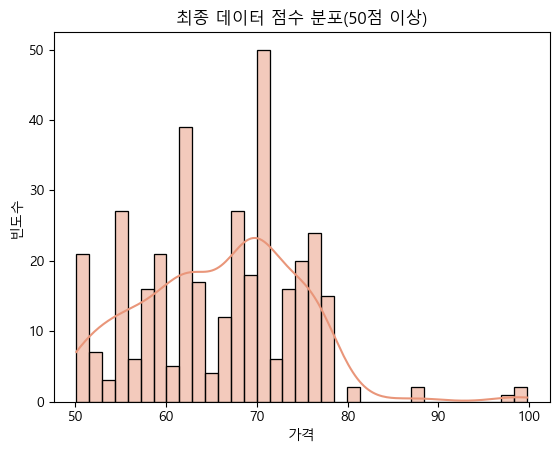

In [45]:
sns.histplot(data= df, x='총 점수', bins=35, kde=True, color='darksalmon')
plt.title('최종 데이터 점수 분포(50점 이상)')
plt.xlabel('가격')
plt.ylabel('빈도수')
plt.show()